In [1]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, spearmanr, chi2_contingency

In [2]:
harim = yf.download('136480.KS', '2016-01-01', '2026-01-01')
kospi = yf.download('^KS11', '2016-01-01', '2026-01-01')

sambok = {
    2016: (pd.Timestamp('2016-07-17'), pd.Timestamp('2016-07-27'), pd.Timestamp('2016-08-16')),
    2017: (pd.Timestamp('2017-07-12'), pd.Timestamp('2017-07-22'), pd.Timestamp('2017-08-11')),
    2018: (pd.Timestamp('2018-07-17'), pd.Timestamp('2018-07-27'), pd.Timestamp('2018-08-16')),
    2019: (pd.Timestamp('2019-07-12'), pd.Timestamp('2019-07-22'), pd.Timestamp('2019-08-11')),
    2020: (pd.Timestamp('2020-07-16'), pd.Timestamp('2020-07-26'), pd.Timestamp('2020-08-15')),
    2021: (pd.Timestamp('2021-07-11'), pd.Timestamp('2021-07-21'), pd.Timestamp('2021-08-10')),
    2022: (pd.Timestamp('2022-07-16'), pd.Timestamp('2022-07-26'), pd.Timestamp('2022-08-15')),
    2023: (pd.Timestamp('2023-07-11'), pd.Timestamp('2023-07-21'), pd.Timestamp('2023-08-10')),
    2024: (pd.Timestamp('2024-07-15'), pd.Timestamp('2024-07-25'), pd.Timestamp('2024-08-14')),
    2025: (pd.Timestamp('2025-07-20'), pd.Timestamp('2025-07-30'), pd.Timestamp('2025-08-19'))
}

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


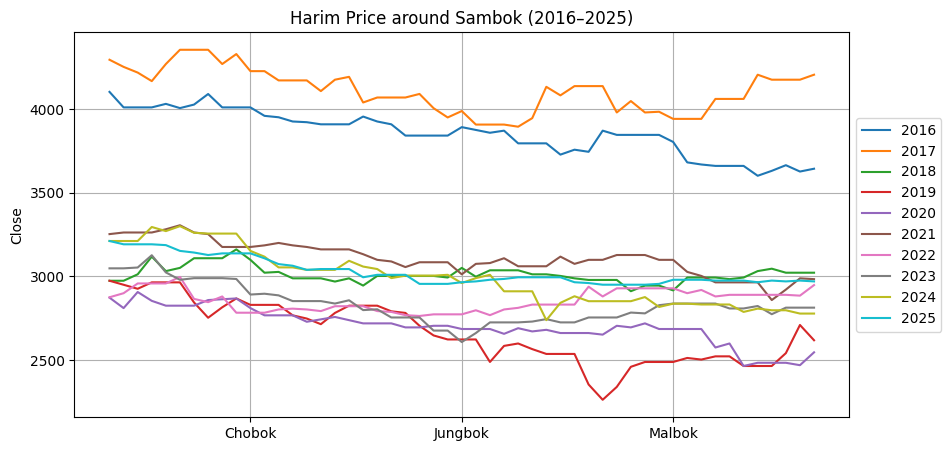

In [3]:
# 데이터 복사
harim_plot = harim.copy()

# 모든 날짜로 채우기
all_days = pd.date_range(start='2016-01-01', end='2025-12-31', freq='D')
harim_plot = harim_plot.reindex(all_days)
harim_plot['Close'] = harim_plot['Close'].ffill()

# 연도별 삼복구간 plotting
plt.figure(figsize=(10,5))
for year in range(2016, 2026):
    start = sambok[year][0] - pd.Timedelta(days=10)
    end = sambok[year][2] + pd.Timedelta(days=10)

    harim_sambok = harim_plot.loc[start:end]
    harim_sambok = harim_sambok.reset_index(drop=True)

    plt.plot(harim_sambok['Close'], label=str(year))

# x축 눈금: 초중말복
tick_dates = [10, 25, 40]
tick_labels = ['Chobok', 'Jungbok', 'Malbok']
plt.xticks(tick_dates, tick_labels)

# 제목, 레이블, 범례, 그리드
plt.title("Harim Price around Sambok (2016–2025)")
plt.xlabel("")
plt.ylabel("Close")
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
plt.grid(True)

plt.show()

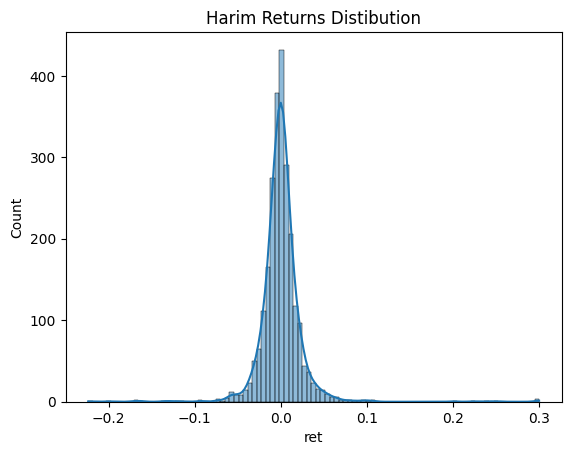

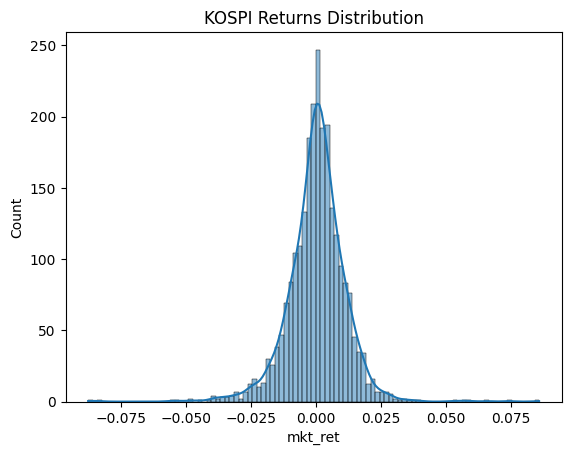

In [4]:
# 직전 데이터 대비 변동률 pct_change()
harim['ret'] = harim['Close'].pct_change()
kospi['mkt_ret'] = kospi['Close'].pct_change()

# 첫째줄 NaN값 제거
harim = harim.dropna()
kospi = kospi.dropna()

sns.histplot(harim['ret'].dropna(), kde=True)
plt.title("Harim Returns Distibution")
plt.show()

sns.histplot(kospi['mkt_ret'].dropna(), kde=True)
plt.title("KOSPI Returns Distribution")
plt.show()

In [5]:

# 각 데이터의 Shapiro-Wilk 정규성 검정(데이터 양이 적을때)
stat, p = shapiro(harim['ret'].dropna())
print("Harim Shapiro-Wilk p-value: ", p)

stat, p = shapiro(kospi['mkt_ret'].dropna())
print("KOSPI Shapiro-Wilk p-value: ", p)

# D'Agostino 정규성 검정(양이 많을 때)
stat, p = normaltest(harim['ret'].dropna())
print("Harim D'Agostino p-value: ", p)

stat, p = normaltest(kospi['mkt_ret'].dropna())
print("KOSPI D'Agostino p-value: ", p)

Harim Shapiro-Wilk p-value:  1.9851322693881065e-53
KOSPI Shapiro-Wilk p-value:  1.42860586082986e-31
Harim D'Agostino p-value:  0.0
KOSPI D'Agostino p-value:  7.548570678351237e-86


In [6]:
# 데이터수 미일치 해결을 위한 merge메서드
data = harim[['ret']].merge(
    kospi[['mkt_ret']],
    left_index=True,
    right_index=True,
    how='inner'
)

# 하림과 코스피의 상관분석
corr, p = spearmanr(data['ret'], data['mkt_ret'])
print("Spearman 상관계수: ", corr)
print("p-value: ", p)

Spearman 상관계수:  0.37711669984089424
p-value:  1.650163804139816e-83


In [7]:
# x, y축 설정
X = sm.add_constant(data['mkt_ret'])
y = data['ret']

# 시장모델 회귀분석 실행(단일)
model = sm.OLS(y, X).fit(cov_type='HC0')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     148.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.04e-33
Time:                        02:29:22   Log-Likelihood:                 5634.4
No. Observations:                2446   AIC:                        -1.126e+04
Df Residuals:                    2444   BIC:                        -1.125e+04
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.002e-06      0.000     -0.004      0.9

In [8]:
data['AR'] = data['ret'] - 0.6636*data['mkt_ret']
print(data['AR'])

Date
2016-01-05   -0.017469
2016-01-06    0.005457
2016-01-07    0.001122
2016-01-08   -0.010819
2016-01-11    0.009129
                ...   
2025-12-23   -0.003491
2025-12-24    0.004708
2025-12-26   -0.008344
2025-12-29   -0.004536
2025-12-30    0.002666
Name: AR, Length: 2446, dtype: float64


In [9]:
# 복날이 주말일경우 월요일로 대체
sambok_update = {
    2016: (pd.Timestamp('2016-07-18'), pd.Timestamp('2016-07-27'), pd.Timestamp('2016-08-16')),
    2017: (pd.Timestamp('2017-07-12'), pd.Timestamp('2017-07-24'), pd.Timestamp('2017-08-11')),
    2018: (pd.Timestamp('2018-07-17'), pd.Timestamp('2018-07-27'), pd.Timestamp('2018-08-16')),
    2019: (pd.Timestamp('2019-07-12'), pd.Timestamp('2019-07-22'), pd.Timestamp('2019-08-12')),
    2020: (pd.Timestamp('2020-07-16'), pd.Timestamp('2020-07-27'), pd.Timestamp('2020-08-18')),
    2021: (pd.Timestamp('2021-07-12'), pd.Timestamp('2021-07-21'), pd.Timestamp('2021-08-10')),
    2022: (pd.Timestamp('2022-07-18'), pd.Timestamp('2022-07-26'), pd.Timestamp('2022-08-16')),
    2023: (pd.Timestamp('2023-07-11'), pd.Timestamp('2023-07-21'), pd.Timestamp('2023-08-10')),
    2024: (pd.Timestamp('2024-07-15'), pd.Timestamp('2024-07-25'), pd.Timestamp('2024-08-14')),
    2025: (pd.Timestamp('2025-07-21'), pd.Timestamp('2025-07-30'), pd.Timestamp('2025-08-19'))
}

# 복날이면 1, 아니면 0으로 설정
data['isbok_event'] = 0
for y in sambok_update:
    for d in sambok_update[y]:
        idx = data.index.get_loc(d)
        data.loc[data.index[idx-3:idx+4], 'isbok_event'] = 1

In [10]:
# 더미회귀(단일)
X = sm.add_constant(data['isbok_event'])
y = data['AR']

model = sm.OLS(y, X).fit(cov_type='HC0')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     10.21
Date:                Wed, 18 Mar 2026   Prob (F-statistic):            0.00142
Time:                        02:29:22   Log-Likelihood:                 5636.3
No. Observations:                2446   AIC:                        -1.127e+04
Df Residuals:                    2444   BIC:                        -1.126e+04
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0003      0.001      0.548      

In [11]:
# 수익률이 양수면 1, 음수면 0으로 설정
data['AR_positive'] = (data['AR'] > 0).astype(int)
print(data['AR_positive'])

Date
2016-01-05    0
2016-01-06    1
2016-01-07    1
2016-01-08    0
2016-01-11    1
             ..
2025-12-23    0
2025-12-24    1
2025-12-26    0
2025-12-29    0
2025-12-30    1
Name: AR_positive, Length: 2446, dtype: int64


AR_positive     0     1
isbok_event            
0            1195  1043
1             128    80


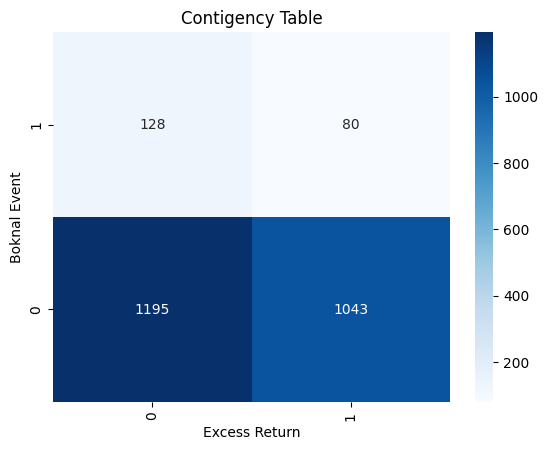

<Figure size 600x600 with 0 Axes>

In [12]:
# 교차표 만들기
contingency = pd.crosstab(data['isbok_event'], data['AR_positive'])
print(contingency)

contingency = contingency.sort_index(ascending=False)
ax = contingency.plot(kind='bar')
sns.heatmap(contingency,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.figure(figsize=(6, 6))
ax.set_xlabel("Excess Return")
ax.set_ylabel("Boknal Event")
ax.set_title("Contigency Table")
ax.legend().remove()
plt.show()

In [13]:
#카이제곱 실행
chi2, p, dof, expected = chi2_contingency(contingency)

print('Chi2 : ', chi2)
print('p-value : ', p)
print('Expected freq :\n', expected)

Chi2 :  4.758562402973081
p-value :  0.02915288758813699
Expected freq :
 [[ 112.50367948   95.49632052]
 [1210.49632052 1027.50367948]]


In [14]:
print(data)

Price            ret   mkt_ret        AR isbok_event AR_positive
Ticker                                                          
Date                                                            
2016-01-05 -0.013398  0.006134 -0.017469           0           0
2016-01-06  0.003704 -0.002642  0.005457           0           1
2016-01-07 -0.006150 -0.010959  0.001122           0           1
2016-01-08 -0.006188  0.006979 -0.010819           0           0
2016-01-11  0.001245 -0.011879  0.009129           0           1
...              ...       ...       ...         ...         ...
2025-12-23 -0.001650  0.002774 -0.003491           0           0
2025-12-24  0.003306 -0.002113  0.004708           0           1
2025-12-26 -0.004942  0.005126 -0.008344           0           0
2025-12-29  0.010067  0.022007 -0.004536           0           0
2025-12-30  0.001661 -0.001514  0.002666           0           1

[2446 rows x 5 columns]


In [18]:
# 이변수 회귀
X = data[['mkt_ret', 'isbok_event']]
X = sm.add_constant(X)
y = data['ret']

# HC0 -> 이분산성을 인정할때 씀
model = sm.OLS(y, X).fit(cov_type='HC0')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     81.65
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.74e-35
Time:                        02:35:52   Log-Likelihood:                 5636.3
No. Observations:                2446   AIC:                        -1.127e+04
Df Residuals:                    2443   BIC:                        -1.125e+04
Df Model:                           2                                         
Covariance Type:                  HC0                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0003    